<a href="https://colab.research.google.com/github/vidhyabala786/Traffic-Accident-Analysis/blob/main/EDA_Traffic_Accident_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ** Exploratory Data Analysis & Visualization of the dataset - "traffic_accidents_c6.csv"**

1. Loading the Dataset
* a. Load the dataset traffic_accidents_c6.csv
* b. Display the first 10 rows


 Got the following error - "MessageError: RangeError : Maximum Call stack size exceeded" while trying to upload the dataset using files module.
 Dataset was too big to upload through files.
 So, I moved traffic_accidents_c6.csv to google drive, mounted the drive and then read the dataset using pandas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive') #Mount to the directory '/content/drive'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#1a.Load the dataset
traffic_accident_df = pd.read_csv('/content/drive/My Drive/traffic_accidents_c6.csv') # access the file inside the mounted drive.
#1b. Display the first 10 rows
traffic_accident_df.head(10)

,crash_date,lighting_condition,first_crash_type,crash_type,prim_contributory_cause,num_units,most_severe_injury,injuries_total,injuries_fatal,crash_hour
0,07/29/2023 01:00:00 PM,DAYLIGHT,TURNING,NO INJURY / DRIVE AWAY,UNABLE TO DETERMINE,2,NO INDICATION OF INJURY,0.0,0.0,13
1,08/13/2023 12:11:00 AM,"DARKNESS, LIGHTED ROAD",TURNING,NO INJURY / DRIVE AWAY,IMPROPER TURNING/NO SIGNAL,2,NO INDICATION OF INJURY,0.0,0.0,0
2,12/09/2021 10:30:00 AM,DAYLIGHT,REAR END,NO INJURY / DRIVE AWAY,FOLLOWING TOO CLOSELY,3,NO INDICATION OF INJURY,0.0,0.0,10
3,08/09/2023 07:55:00 PM,DAYLIGHT,ANGLE,INJURY AND / OR TOW DUE TO CRASH,UNABLE TO DETERMINE,2,NONINCAPACITATING INJURY,5.0,0.0,19
4,08/19/2023 02:55:00 PM,DAYLIGHT,REAR END,NO INJURY / DRIVE AWAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,2,NO INDICATION OF INJURY,0.0,0.0,14
5,09/06/2023 12:59:00 AM,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,INJURY AND / OR TOW DUE TO CRASH,UNABLE TO DETERMINE,1,NONINCAPACITATING INJURY,2.0,0.0,0
6,12/20/2022 11:45:00 AM,DAYLIGHT,REAR TO FRONT,NO INJURY / DRIVE AWAY,IMPROPER BACKING,2,NO INDICATION OF INJURY,0.0,0.0,11
7,09/20/2023 02:38:00 PM,DAYLIGHT,ANGLE,INJURY AND / OR TOW DUE TO CRASH,FAILING TO YIELD RIGHT-OF-WAY,2,NONINCAPACITATING INJURY,1.0,0.0,14
8,06/04/2018 06:42:00 PM,DAYLIGHT,REAR END,NO INJURY / DRIVE AWAY,FOLLOWING TOO CLOSELY,2,NO INDICATION OF INJURY,0.0,0.0,18
9,09/07/2023 05:30:00 PM,DAYLIGHT,ANGLE,NO INJURY / DRIVE AWAY,FAILING TO YIELD RIGHT-OF-WAY,2,NO INDICATION OF INJURY,0.0,0.0,17


2. Data Cleaning and Manipulation:

* a.Check for missing values and handle them appropriately.
* b.Create a new column crash_month to store the accident month as a name (Jan,
Feb etc)
* c.Create a new column crash_day to store the accident day as a name (Monday, Tuesday etc)

In [ ]:
#2a. Check for missing values using isnull() and sum()
missing_values = traffic_accident_df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 crash_date                 0
lighting_condition         0
first_crash_type           0
crash_type                 0
prim_contributory_cause    0
num_units                  0
most_severe_injury         0
injuries_total             0
injuries_fatal             0
crash_hour                 0
dtype: int64


In [ ]:
#2b.Create a new column crash_month to store the accident month as a name (Jan, Feb etc)

traffic_accident_df['crash_date'] = pd.to_datetime(traffic_accident_df['crash_date'])

# Create the 'crash_month' column using dt.month_name()
traffic_accident_df['crash_month'] = traffic_accident_df['crash_date'].dt.month_name()

# Display the updated DataFrame
print(traffic_accident_df[['crash_date', 'crash_month']].head(10))

/tmp/ipykernel_5623/499115571.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  traffic_accident_df['crash_date'] = pd.to_datetime(traffic_accident_df['crash_date'])


           crash_date crash_month
0 2023-07-29 13:00:00        July
1 2023-08-13 00:11:00      August
2 2021-12-09 10:30:00    December
3 2023-08-09 19:55:00      August
4 2023-08-19 14:55:00      August
5 2023-09-06 00:59:00   September
6 2022-12-20 11:45:00    December
7 2023-09-20 14:38:00   September
8 2018-06-04 18:42:00        June
9 2023-09-07 17:30:00   September


In [ ]:
#2c. Create the 'crash_day' column using dt.day_name()
traffic_accident_df['crash_day'] = traffic_accident_df['crash_date'].dt.day_name()

# Display the updated DataFrame
print(traffic_accident_df[['crash_date', 'crash_month', 'crash_day']].head(10))

           crash_date crash_month  crash_day
0 2023-07-29 13:00:00        July   Saturday
1 2023-08-13 00:11:00      August     Sunday
2 2021-12-09 10:30:00    December   Thursday
3 2023-08-09 19:55:00      August  Wednesday
4 2023-08-19 14:55:00      August   Saturday
5 2023-09-06 00:59:00   September  Wednesday
6 2022-12-20 11:45:00    December    Tuesday
7 2023-09-20 14:38:00   September  Wednesday
8 2018-06-04 18:42:00        June     Monday
9 2023-09-07 17:30:00   September   Thursday


3. Data Summary:

* a. Identify and list categorical columns.
* b. Count the number of unique values for each categorical variable.
* c. Generate descriptive statistics for numerical features.





In [ ]:
# 3a. Identify and list categorical columns.
categorical_cols = traffic_accident_df.select_dtypes(include=['object', 'category']).columns.tolist()

# print("Categorical columns:", categorical_cols)
print("Categorical columns:")
for column in categorical_cols:
   print(column)

Categorical columns:
lighting_condition
first_crash_type
crash_type
prim_contributory_cause
most_severe_injury
crash_month
crash_day


In [ ]:
#3b. Count the number of unique values for each categorical variable.(Display 1)
print("Unique value counts for categorical variables:")
for column in categorical_cols:
    unique_count = traffic_accident_df[column].nunique()
    print(f"- {column}: {unique_count}")

Unique value counts for categorical variables:
- lighting_condition: 6
- first_crash_type: 18
- crash_type: 2
- prim_contributory_cause: 40
- most_severe_injury: 5
- crash_month: 12
- crash_day: 7


In [ ]:
#3b. Count the number of unique values for each categorical variable.(Display 2(Readability))
print("Unique value counts for categorical variables:")
unique_counts = traffic_accident_df[categorical_cols].nunique()
print(unique_counts)

Unique value counts for categorical variables:
lighting_condition          6
first_crash_type           18
crash_type                  2
prim_contributory_cause    40
most_severe_injury          5
crash_month                12
crash_day                   7
dtype: int64


In [ ]:
#3c.Generate descriptive statistics for numerical features.
Descriptive_statistics = traffic_accident_df.describe()
Descriptive_statistics

,crash_date,num_units,injuries_total,injuries_fatal,crash_hour
count,209306,209306.000000,209306.000000,209306.000000,209306.000000
mean,2020-12-08 23:26:35.213802240,2.063300,0.382717,0.001859,13.373047
min,2013-03-03 16:48:00,1.000000,0.000000,0.000000,0.000000
25%,2018-12-03 10:18:45,2.000000,0.000000,0.000000,9.000000
50%,2020-12-19 16:39:00,2.000000,0.000000,0.000000,14.000000
75%,2023-01-08 02:33:45,2.000000,1.000000,0.000000,17.000000
max,2025-01-18 00:17:00,11.000000,21.000000,3.000000,23.000000
std,NaN,0.396012,0.799720,0.047502,5.603830


4. Time-Based Trends:

* a. Visualize the number of accidents per month using a line plot.
* b. Visualize the number of accidents per day of the week using a bar chart.
* c. Identify the most accident-prone hour of the day and visualize it using an appropriate plot.
* d. Compare the number of accidents that occurred in daylight and in darkness using two lines on the same plot.


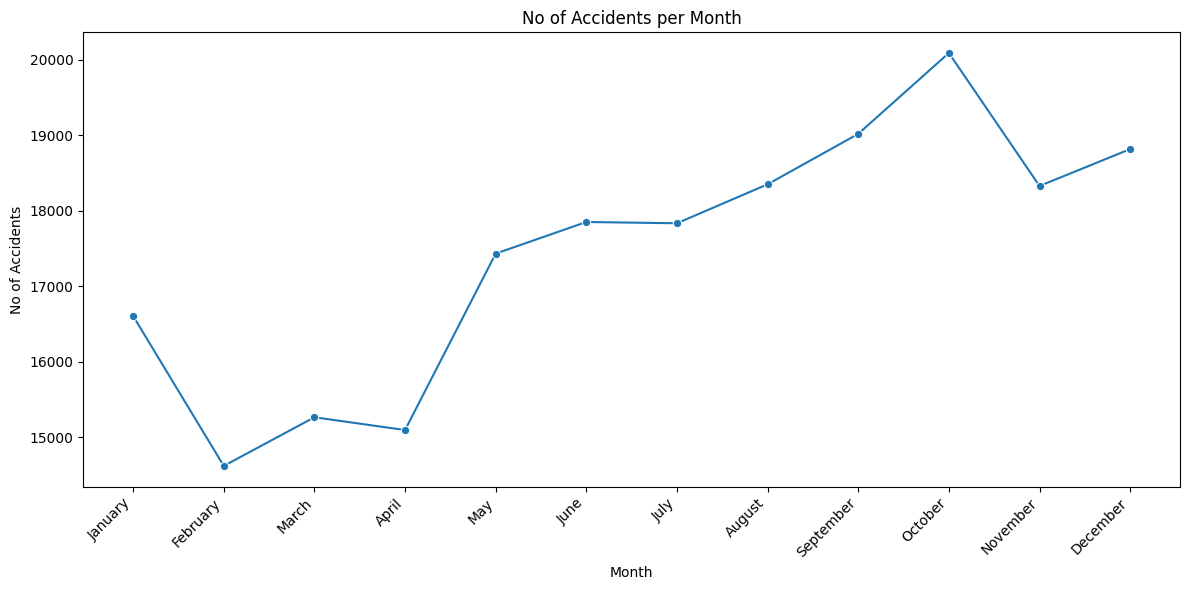

In [ ]:
#4a. Visualize the number of accidents per month using a line plot.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

accidents_in_month = traffic_accident_df.groupby('crash_month')['crash_date'].count().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
accidents_in_month['crash_month'] = pd.Categorical(accidents_in_month['crash_month'], categories=month_order, ordered=True)
accidents_in_month = accidents_in_month.sort_values('crash_month')


plt.figure(figsize=(12, 6))
sns.lineplot(x='crash_month', y='crash_date', data=accidents_in_month, marker='o')
plt.title('No of Accidents per Month')
plt.xlabel('Month')
plt.ylabel('No of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

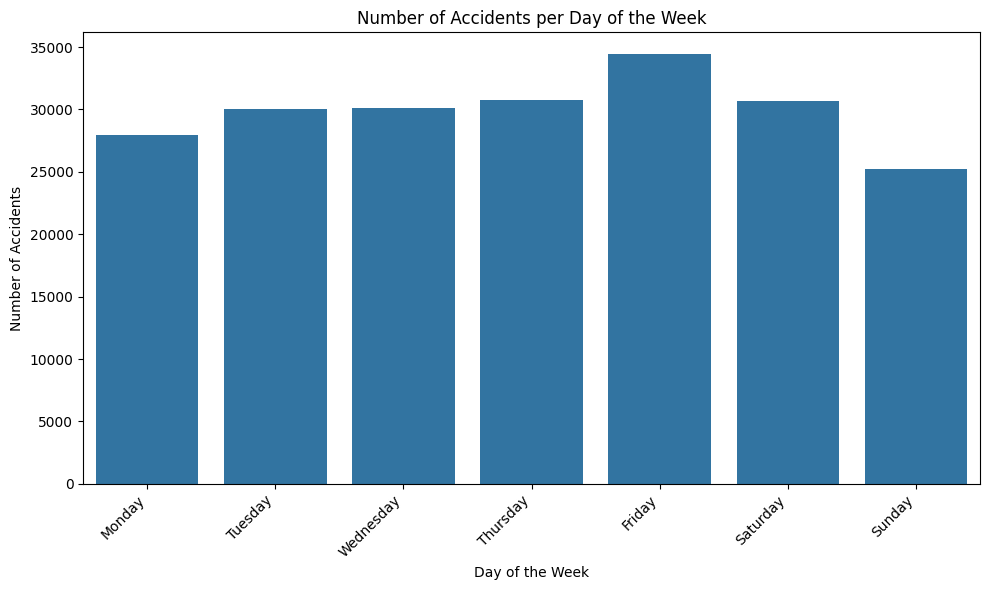

In [ ]:
#4b. Visualize the number of accidents per day of the week using a bar chart.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


accidents_per_day = traffic_accident_df.groupby('crash_day')['crash_date'].count().reset_index()


accidents_per_day = accidents_per_day.rename(columns={'crash_date': 'accident_count'})


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_per_day['crash_day'] = pd.Categorical(accidents_per_day['crash_day'], categories=day_order, ordered=True)
accidents_per_day = accidents_per_day.sort_values('crash_day')

plt.figure(figsize=(10, 6))
sns.barplot(x='crash_day', y='accident_count', data=accidents_per_day)
plt.title('Number of Accidents per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

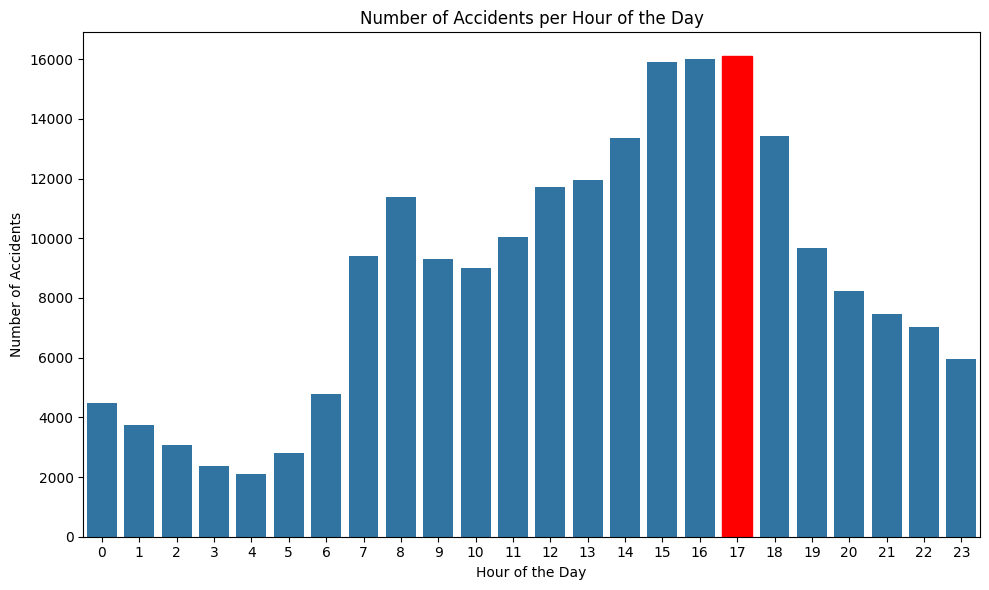

In [ ]:
#4c. Identify the most accident-prone hour of the day and visualize it using an appropriate plot.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


accidents_per_hour = traffic_accident_df.groupby('crash_hour')['crash_date'].count().reset_index()

accidents_per_hour = accidents_per_hour.rename(columns={'crash_date': 'accident_count'})

most_accident_hour = accidents_per_hour.loc[accidents_per_hour['accident_count'].idxmax(), 'crash_hour']

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='crash_hour', y='accident_count', data=accidents_per_hour)
plt.title('Number of Accidents per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')

for bar in barplot.patches:
    if bar.get_x() + bar.get_width() / 2 == most_accident_hour:
       bar.set_color('Red')
plt.tight_layout()
plt.show()

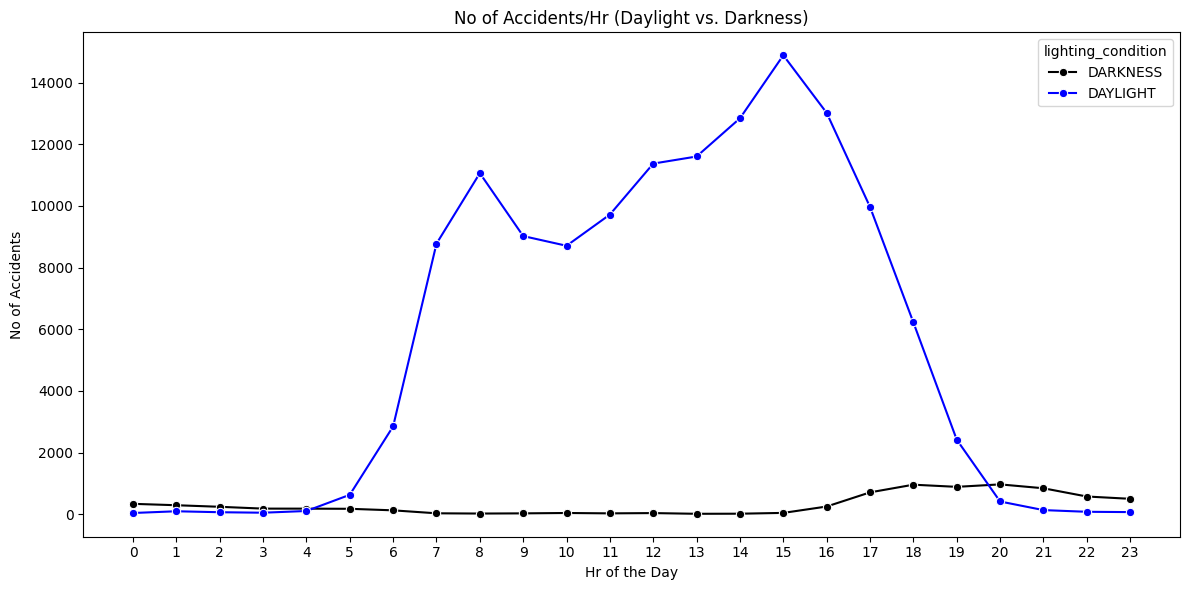

In [ ]:
#4d.Compare the number of accidents that occurred in daylight and in darkness using two lines on the same plot.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

accidents_per_hour_daylight = traffic_accident_df.groupby(['crash_hour', 'lighting_condition'])['crash_date'].count().reset_index()

accidents_per_hour_daylight = accidents_per_hour_daylight.rename(columns={'crash_date': 'accident_count'})

accidents_per_hour_daylight = accidents_per_hour_daylight[accidents_per_hour_daylight['lighting_condition'].
                                                          isin(['DAYLIGHT', 'DARKNESS'])]

plt.figure(figsize=(12, 6))
ax = sns.lineplot(x='crash_hour', y='accident_count', hue='lighting_condition',
                  data=accidents_per_hour_daylight, marker='o',
                  palette={'DAYLIGHT': 'blue', 'DARKNESS': 'black'})
plt.title('No of Accidents/Hr (Daylight vs. Darkness)')
plt.xlabel('Hr of the Day')
plt.ylabel('No of Accidents')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

5. Bar Charts : Crash Type and Injury Analysis

* a. Identify the top 5 most common crash types and visualize them using a bar chart.
* b. Identify the top 5 causes of accidents and visualize them using a bar chart.
* c. Display the number of fatal injuries at each hour of the day using a bar chart.

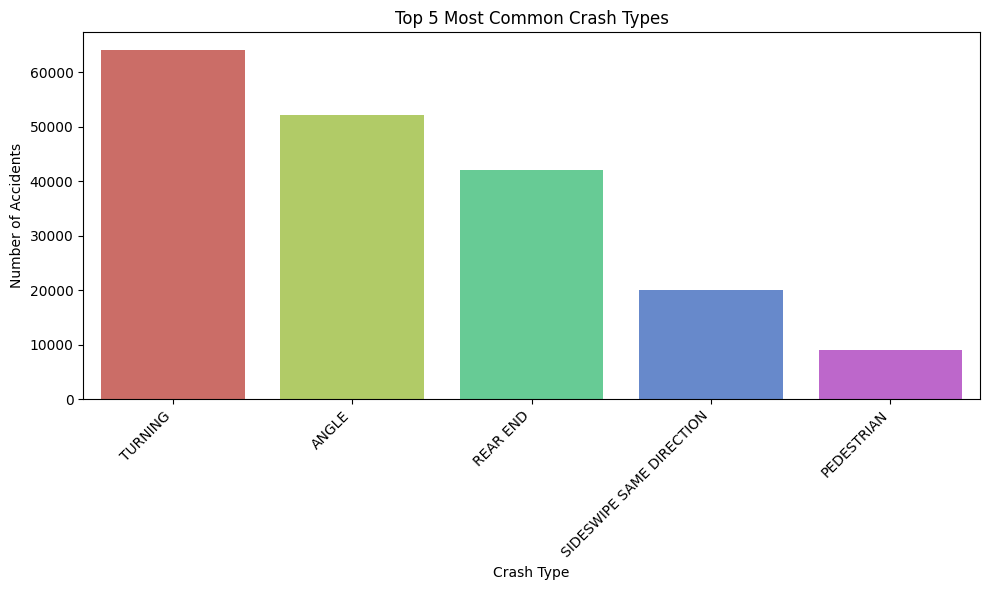

In [ ]:
#5a. Identify the top 5 most common crash types and visualize them using a bar chart.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

crash_type_counts = traffic_accident_df.groupby('first_crash_type')['crash_date'].count().reset_index()

crash_type_counts = crash_type_counts.rename(columns={'crash_date': 'accident_count'})

top_5_crash_types = crash_type_counts.sort_values('accident_count', ascending=False).head(5)

num_crash_types = len(top_5_crash_types['first_crash_type'].unique())
palette = sns.color_palette("hls", num_crash_types)

plt.figure(figsize=(10, 6))
sns.barplot(x='first_crash_type', y='accident_count', data=top_5_crash_types,
            hue='first_crash_type', palette=palette, dodge=False, legend=False)
plt.title('Top 5 Most Common Crash Types')
plt.xlabel('Crash Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

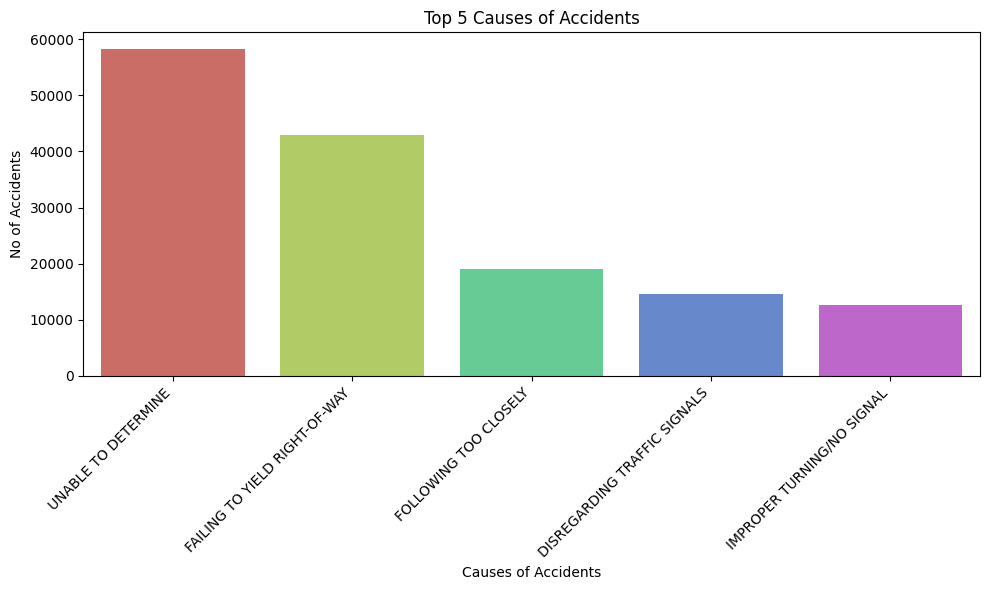

In [ ]:
#5b. Identify the top 5 causes of accidents and visualize them using a bar chart.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

acc_cause_counts = traffic_accident_df.groupby('prim_contributory_cause')['crash_date'].count().reset_index()

acc_cause_counts = acc_cause_counts.rename(columns={'crash_date': 'accident_count'})

# Sort by accident count and get the top 5 causes
top_5_causes = acc_cause_counts.sort_values('accident_count', ascending=False).head(5)
num_crash_causes = len(top_5_causes['prim_contributory_cause'].unique())
palette = sns.color_palette("hls", num_crash_causes)


# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='prim_contributory_cause', y='accident_count', data=top_5_causes, hue='prim_contributory_cause', palette=palette,  dodge=False, legend=False)
plt.title('Top 5 Causes of Accidents')
plt.xlabel('Causes of Accidents')
plt.ylabel('No of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

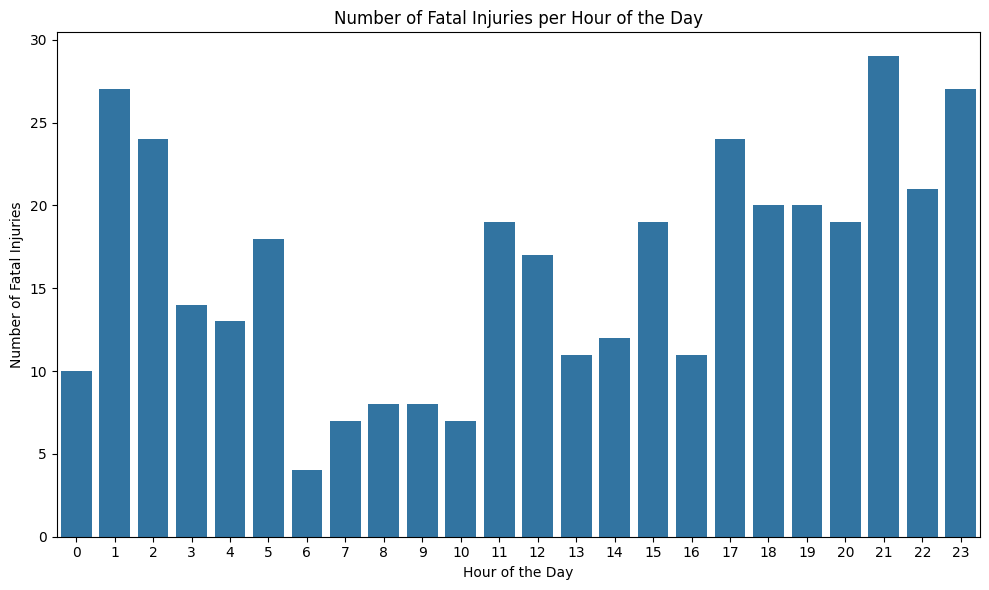

In [ ]:
#5c. Display the number of fatal injuries at each hour of the day using a bar chart.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fatal_injuries_per_hour = traffic_accident_df.groupby('crash_hour')['injuries_fatal'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='crash_hour', y='injuries_fatal', data=fatal_injuries_per_hour)
plt.title('Number of Fatal Injuries per Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Fatal Injuries')
plt.tight_layout()
plt.show()

In [ ]:
print(traffic_accident_df.columns)

Index(['crash_date', 'lighting_condition', 'first_crash_type', 'crash_type',
       'prim_contributory_cause', 'num_units', 'most_severe_injury',
       'injuries_total', 'injuries_fatal', 'crash_hour', 'crash_month',
       'crash_day'],
      dtype='object')


6. Heatmap Analysis:
* a. Create a heatmap to analyze accident occurrences across different hours of the day and days of the week.

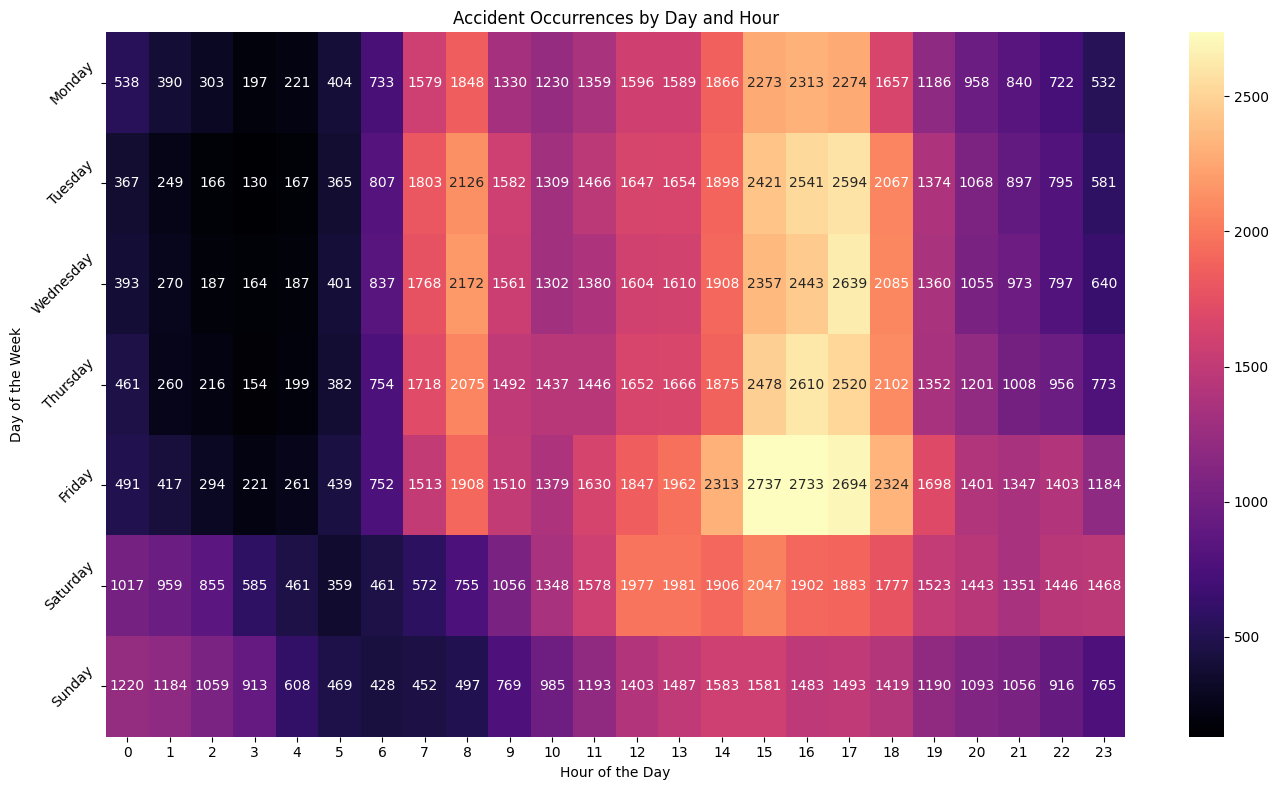

In [ ]:
#6a. Create a heatmap to analyze accident occurrences across different hours of the day and days of the week.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

accidents_by_day_hour = traffic_accident_df.groupby(['crash_day', 'crash_hour'])['crash_date'].count().reset_index()

accidents_heatmap_data = accidents_by_day_hour.pivot(index="crash_day",
                                                     columns="crash_hour", values="crash_date")

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
accidents_heatmap_data = accidents_heatmap_data.reindex(day_order)


plt.figure(figsize=(14, 8))
sns.heatmap(accidents_heatmap_data, cmap="magma", annot=True, fmt="d")
plt.title('Accident Occurrences by Day and Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.yticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()